<a href="https://colab.research.google.com/github/MengOonLee/Deep_learning/blob/master/Experiments/Probabilistic/VAE/VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Variational autoencoders

## Coding tutorials

#### [1. Encoders and decoders](#tutorial1)
#### [2. Minimising Kullback-Leibler divergence](#tutorial2)
#### [3. Maximising the ELBO](#tutorial3)
#### [4. KL divergence layers](#tutorial4)

In [ ]:
%%bash
pip install --no-cache-dir -qU pip
pip install --no-cache-dir -qU \
    torch torchvision lightning torchmetrics

***
<a class="anchor" id="tutorial1"></a>
## Encoders and Decoders

#### Examples

Seed set to 42


Total training time: 4.2857s


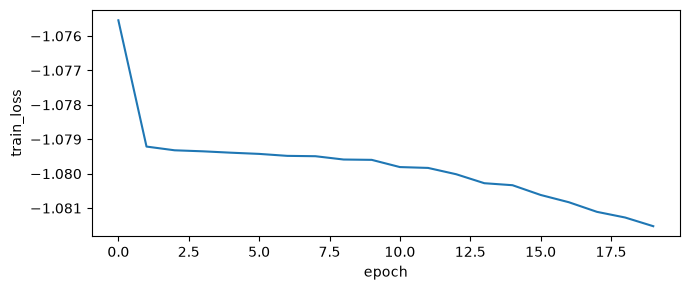

Norm of difference: 7.899128


In [ ]:
import os
import time
import torch
import lightning.pytorch as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import logging
logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)

pl.seed_everything(seed=42, workers=True)

class AutoEncoder(pl.LightningModule):
    def __init__(self, latent_dim: int=2):
        super().__init__()
        self.save_hyperparameters()
        self.encoder = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(in_features=28*28, out_features=256),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=256, out_features=64),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=64, out_features=latent_dim)
        )
        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(in_features=latent_dim, out_features=64),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=64, out_features=256),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=256, out_features=28*28),
            torch.nn.Sigmoid(),
            torch.nn.Unflatten(dim=1, unflattened_size=(1, 28, 28))
        )
        self.criterion = torch.nn.MSELoss()

    def forward(self, x: torch.Tensor):
        z = self.encoder(x)
        return self.decoder(z)

    def configure_optimizers(self):
        return torch.optim.RMSprop(params=self.parameters(), lr=0.001)

    def training_step(self, batch, batch_idx):
        (x,) = batch
        x_hat = self(x)

        loss = self.criterion(input=x_hat, target=x)
        self.log(name="train_loss", value=torch.log10(loss),
            on_step=False, on_epoch=True, sync_dist=True
        )
        return loss

class SyntheticDataModule(pl.LightningDataModule):
    def __init__(self, x_train: torch.Tensor, batch_size: int=32):
        super().__init__()
        self.batch_size = batch_size
        self.x_train = x_train

    def setup(self, stage: str=None):
        self.ds_train = torch.utils.data.TensorDataset(self.x_train)

    def train_dataloader(self):
        return torch.utils.data.DataLoader(dataset=self.ds_train,
            shuffle=True, batch_size=self.batch_size,
            num_workers=os.cpu_count(), pin_memory=True)

x_train = torch.rand(size=(1000, 1, 28, 28))
dm = SyntheticDataModule(x_train=x_train)
model = AutoEncoder()

csv_logger = pl.loggers.CSVLogger(save_dir="./lightning_logs", name="AutoEncoder",
    version="test")
model_ckpt = pl.callbacks.ModelCheckpoint(monitor="train_loss", mode="min",
    dirpath="./ckpt", filename="epoch-{epoch}_loss-{train_loss:.6f}")
early_stopping = pl.callbacks.EarlyStopping(monitor="train_loss", mode="min",
    patience=3)
trainer = pl.Trainer(max_epochs=20, logger=csv_logger, log_every_n_steps=1,
    accelerator="auto", enable_progress_bar=False, enable_model_summary=False,
    callbacks=[model_ckpt, early_stopping])

if __name__ == "__main__":
    start_time = time.time()

    trainer.fit(model=model, datamodule=dm)

    end_time = time.time() - start_time
    print("Total training time: %.4fs"%end_time)

metrics_path = os.path.join(trainer.logger.log_dir, "metrics.csv")
df_metrics = pd.read_csv(metrics_path)

plt.figure(figsize=(7, 3))
sns.lineplot(data=df_metrics, x="epoch", y="train_loss")
plt.tight_layout()
plt.show()

best_ckpt_path = model_ckpt.best_model_path
model = AutoEncoder.load_from_checkpoint(checkpoint_path=best_ckpt_path)

x_sample = torch.rand(size=(1, 1, 28, 28))
model.eval()
with torch.no_grad():
    x_recon = model(x=x_sample.to(model.device))

diff_norm = torch.norm(input=x_recon - x_sample)
print("Norm of difference: %.6f"%diff_norm.item())

#### Fashion MNIST

Seed set to 42


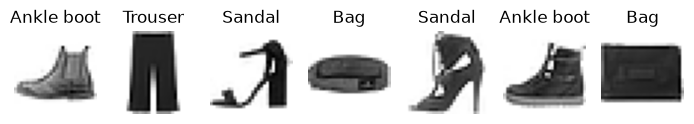

In [ ]:
import os
import numpy as np
import torch
import torchvision
import lightning.pytorch as pl
import matplotlib.pyplot as plt

pl.seed_everything(seed=42, workers=True)

class FashionMNISTDataModule(pl.LightningDataModule):
    def __init__(self, data_dir: str="./data", sample_size: int=1000):
        super().__init__()
        self.data_dir = data_dir
        self.sample_size = sample_size
        self.transform = torchvision.transforms.Compose(transforms=[
            torchvision.transforms.ToTensor()
        ])
        self.class_to_idx = None

    def prepare_data(self):
        torchvision.datasets.FashionMNIST(root=self.data_dir, train=True,
            download=True)
        torchvision.datasets.FashionMNIST(root=self.data_dir, train=False,
            download=True)

    def setup(self, stage: str=None):
        if stage=="fit" or stage is None:
            ds = torchvision.datasets.FashionMNIST(root=self.data_dir,
                train=True, transform=self.transform)

            if self.class_to_idx is None:
                self.class_to_idx = ds.class_to_idx

            self.ds_train, self.ds_val = torch.utils.data.random_split(
                dataset=ds, lengths=[0.9, 0.1],
                generator=torch.Generator().manual_seed(42))

        if stage in ["test", "predict"] or stage is None:
            ds = torchvision.datasets.FashionMNIST(root=self.data_dir,
                train=False, transform=self.transform)

            if self.class_to_idx is None:
                self.class_to_idx = ds.class_to_idx

            self.ds_test = ds

            indices = torch.randperm(n=len(ds),
                generator=torch.Generator().manual_seed(42))
            self.ds_sample = torch.utils.data.Subset(dataset=ds,
                indices=indices[:self.sample_size])

    def train_dataloader(self):
        return torch.utils.data.DataLoader(dataset=self.ds_train, shuffle=True,
            batch_size=64, num_workers=os.cpu_count(), pin_memory=True)

    def val_dataloader(self):
        return torch.utils.data.DataLoader(dataset=self.ds_val, shuffle=False,
            batch_size=64, num_workers=os.cpu_count(), pin_memory=True)

    def test_dataloader(self):
        return torch.utils.data.DataLoader(dataset=self.ds_test, shuffle=False,
            batch_size=64, num_workers=os.cpu_count(), pin_memory=False)

    def predict_dataloader(self):
        return torch.utils.data.DataLoader(dataset=self.ds_sample, shuffle=False,
            batch_size=64, num_workers=os.cpu_count(), pin_memory=False)

if __name__ == "__main__":
    dm = FashionMNISTDataModule()
    dm.prepare_data()
    dm.setup(stage="predict")
    ds_predict = dm.predict_dataloader()

x_samples, y_samples = zip(*list(ds_predict))
x_sample = torch.cat(tensors=x_samples, dim=0)
y_sample = torch.cat(tensors=y_samples, dim=0)

idx_to_class = {v: k for k, v in dm.class_to_idx.items()}
y_sample = np.array([idx_to_class[i] for i in y_sample.numpy()])

fig, axes = plt.subplots(nrows=1, ncols=7, figsize=(7, 3))
for i, ax in enumerate(axes):
    ax.set_title(label=y_sample[i])
    ax.imshow(X=x_sample[i].squeeze().numpy(), cmap="binary")
    ax.axis("off")
plt.tight_layout()
plt.show()

Seed set to 42


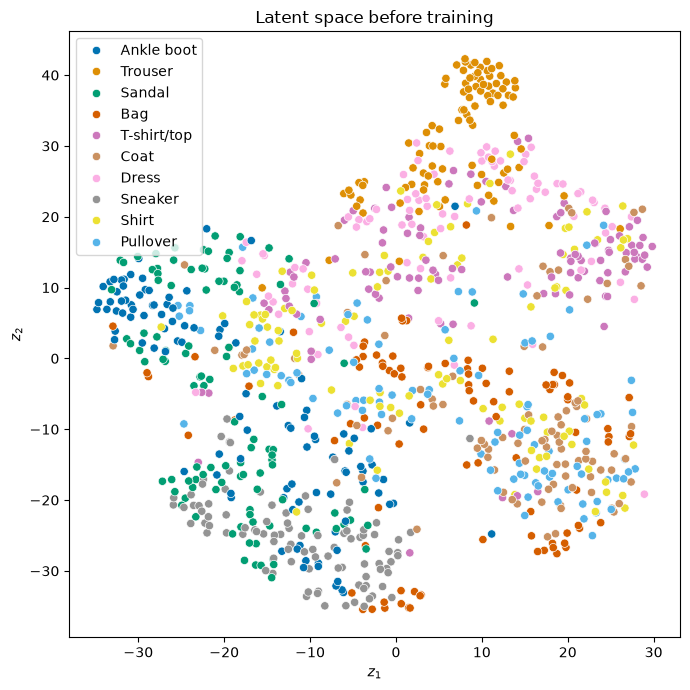

In [ ]:
import torch
import lightning.pytorch as pl
import torchmetrics
from sklearn import manifold
import matplotlib.pyplot as plt
import seaborn as sns

pl.seed_everything(seed=42, workers=True)

# Autoencoder model
class AutoEncoder(pl.LightningModule):
    def __init__(self, latent_dim: int=2, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        # Define the encoder
        self.encoder = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=1, out_channels=32, kernel_size=(3, 3),
                stride=(2, 2), padding=(1, 1)),
            torch.nn.ReLU(),
            torch.nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3, 3),
                stride=(2, 2), padding=(1, 1)),
            torch.nn.ReLU(),
            torch.nn.Flatten(),
            torch.nn.Linear(in_features=64*7*7, out_features=latent_dim)
        )
        # Define the decoder
        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(in_features=latent_dim, out_features=64*7*7),
            torch.nn.ReLU(),
            torch.nn.Unflatten(dim=1, unflattened_size=(64, 7, 7)),
            torch.nn.ConvTranspose2d(in_channels=64, out_channels=64,
                kernel_size=(3, 3), stride=(2, 2), padding=(1, 1),
                output_padding=(1, 1)),
            torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(in_channels=64, out_channels=32,
                kernel_size=(3, 3), stride=(2, 2), padding=(1, 1),
                output_padding=(1, 1)),
            torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(in_channels=32, out_channels=1,
                kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            torch.nn.Sigmoid()
        )

        self.train_r2score = torchmetrics.regression.R2Score()
        self.val_r2score = torchmetrics.regression.R2Score()
        self.test_r2score = torchmetrics.regression.R2Score()

    def forward(self, x: torch.Tensor):
        z = self.encoder(x)
        x_pred = self.decoder(z)
        return x_pred

    def _compute_loss(self, x: torch.Tensor, x_pred: torch.Tensor):
        # BCE loss for normalized pixel values [0., 1.],
        loss = torch.nn.functional.binary_cross_entropy(
            input=x_pred, target=x, reduction='none')
        return loss.sum(dim=[1, 2, 3]).mean(dim=0)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(params=self.parameters(),
            lr=self.hparams.lr))

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer=optimizer, mode='min', factor=0.1, patience=3)

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss",
                "frequency": 1
            }
        }

    def training_step(self, batch, batch_idx):
        x, _ = batch
        x_pred = self(x)

        loss = self._compute_loss(x=x, x_pred=x_pred)
        self.log(name='train_loss', value=torch.log10(loss),
            on_step=False, on_epoch=True, sync_dist=True)

        self.train_r2score.update(preds=x_pred.view(-1), target=x.view(-1))
        self.log(name='train_r2score', value=self.train_r2score,
            on_step=False, on_epoch=True, sync_dist=True)

        return loss

    def validation_step(self, batch, batch_idx):
        x, _ = batch
        x_pred = self(x)

        loss = self._compute_loss(x=x, x_pred=x_pred)
        self.log(name="val_loss", value=torch.log10(loss),
            on_step=False, on_epoch=True, sync_dist=True)

        self.val_r2score.update(preds=x_pred.view(-1), target=x.view(-1))
        self.log(name="val_r2score", value=self.val_r2score,
            on_step=False, on_epoch=True, sync_dist=True)

    def test_step(self, batch, batch_idx):
        x, _ = batch
        x_pred = self(x)

        loss = self._compute_loss(x=x, x_pred=x_pred)
        self.log(name="test_loss", value=torch.log10(loss),
            on_step=False, on_epoch=True, sync_dist=True)

        self.test_r2score.update(preds=x_pred.view(-1), target=x.view(-1))
        self.log(name="test_r2score", value=self.test_r2score,
            on_step=False, on_epoch=True, sync_dist=True)

    def predict_step(self, batch, batch_idx):
        x, _ = batch
        z = self.encoder(x)
        x_pred = self.decoder(z)
        return {
            "z": z,
            "x_pred": x_pred
        }

latent_dim = 8
model = AutoEncoder(latent_dim=latent_dim)
model.eval()
with torch.no_grad():
    z_pretrain = model.encoder(x_sample.to(model.device))

tsne = manifold.TSNE(n_components=2, random_state=42)
z_pretrain = tsne.fit_transform(X=z_pretrain.numpy())

plt.figure(figsize=(7, 7))
plt.title(label="Latent space before training")
sns.scatterplot(x=z_pretrain[:, 0], y=z_pretrain[:, 1], hue=y_sample,
    palette=sns.color_palette(palette="colorblind", n_colors=10))
plt.xlabel(xlabel=r"$z_1$")
plt.ylabel(ylabel=r"$z_2$")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

In [ ]:
import os
import time
import lightning.pytorch as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pl.seed_everything(seed=42, workers=True)

csv_logger = pl.loggers.CSVLogger(save_dir="./lightning_logs", name="AutoEncoder",
    version="test")
model_ckpt = pl.callbacks.ModelCheckpoint(monitor="val_loss", mode="min",
    dirpath="./ckpt", filename="{epoch}_{val_loss:.6f}")
early_stopping = pl.callbacks.EarlyStopping(monitor="val_loss",
    mode="min", patience=5)
lr_monitor = pl.callbacks.LearningRateMonitor(logging_interval="epoch")
trainer = pl.Trainer(max_epochs=30, logger=csv_logger, log_every_n_steps=1,
    accelerator="cpu", devices=os.cpu_count(), strategy="ddp_notebook",
    enable_progress_bar=True, enable_model_summary=True,
    callbacks=[model_ckpt, early_stopping, lr_monitor])

if __name__ == "__main__":
    start_time = time.time()

    model.train()
    trainer.fit(model=model, datamodule=dm)

    end_time = time.time() - start_time
    print("Total training time: %.4fs"%end_time)

metrics_path = os.path.join(trainer.logger.log_dir, "metrics.csv")
df_metrics = pd.read_csv(metrics_path)

df_metrics = df_metrics.groupby("epoch").agg({
    "train_loss": "mean", "train_r2score": "mean",
    "val_loss": "mean", "val_r2score": "mean"
}).reset_index()

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(7, 5), sharex=True)
for ax, m in zip(axes, ["loss", "r2score"]):
    sns.lineplot(ax=ax, data=df_metrics, x="epoch", y=f"train_{m}",
        label="train")
    sns.lineplot(ax=ax, data=df_metrics, x="epoch", y=f"val_{m}",
        label="val")
    ax.set_ylabel(ylabel=f"{m}")
    ax.set_title(label=f"{m} vs. epoch")
    ax.legend(loc="best")
plt.tight_layout()
plt.show()

Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │    2.3469996452331543     │
│       test_r2score        │    0.8883576393127441     │
└───────────────────────────┴───────────────────────────┘

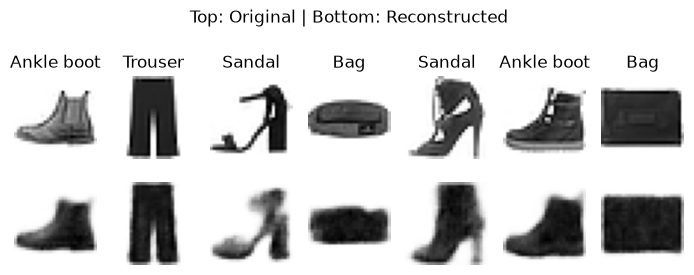

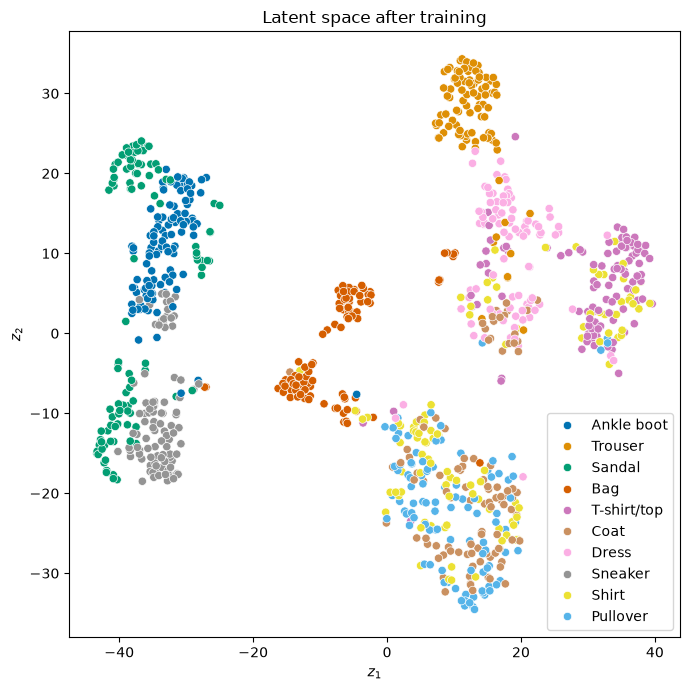

In [ ]:
import numpy as np
import torch
import lightning.pytorch as pl
import matplotlib.pyplot as plt
import seaborn as sns

pl.seed_everything(seed=42, workers=True)

best_ckpt_path = model_ckpt.best_model_path
model = AutoEncoder.load_from_checkpoint(latent_dim=latent_dim,
    checkpoint_path=best_ckpt_path)

trainer = pl.Trainer(accelerator="cpu", devices=1,
    enable_progress_bar=False, enable_model_summary=False)

if __name__ == "__main__":
    model.eval()
    trainer.test(model=model, datamodule=dm)
    predictions = trainer.predict(model=model, datamodule=dm)
    predictions = {k: torch.cat([p[k] for p in predictions], dim=0)
        for k in predictions[0].keys()}

x_hat_sample = predictions['x_pred']
fig, axes = plt.subplots(nrows=2, ncols=7, figsize=(7, 3))
fig.suptitle(t="Top: Original | Bottom: Reconstructed")
for i in range(7):
    ax = axes[0, i]
    ax.set_title(label=y_sample[i])
    ax.imshow(X=x_sample[i].squeeze().numpy(), cmap='binary')
    ax.axis('off')

    ax = axes[1, i]
    ax.imshow(X=x_hat_sample[i].squeeze().numpy(), cmap='binary')
    ax.axis('off')
plt.tight_layout()
plt.show()

z_trained = predictions["z"]
z_trained = tsne.fit_transform(X=z_trained.numpy())

plt.figure(figsize=(7, 7))
plt.title(label="Latent space after training")
sns.scatterplot(x=z_trained[:, 0], y=z_trained[:, 1], hue=y_sample,
    palette=sns.color_palette(palette="colorblind", n_colors=10))
plt.xlabel(xlabel=r"$z_1$")
plt.ylabel(ylabel=r"$z_2$")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

***
<a class="anchor" id="tutorial2"></a>
## Minimising Kullback-Leibler divergence

In [ ]:
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import tensorflow_probability as tfp

# KL(q || p) = E_{z ~ q}[log q(z) - log p(z)]

# tfp.bijectors.Chain(bijectors=[
#     tfp.bijectors.TransformDiagonal(diag_bijector=tfp.bijectors.Chain(bijectors=[
#         tfp.bijectors.Shift(shift=1e-5),
#         tfp.bijectors.Softplus()])),
#     tfp.bijectors.FillTriangular()
# ])

scale_tril = tfp.bijectors.FillScaleTriL().forward(x=[-0.5, 1.25, 1.])
p = tfp.distributions.MultivariateNormalTriL(loc=0., scale_tril=scale_tril)

q = tfp.distributions.MultivariateNormalDiag(
    loc=tf.Variable(initial_value=tf.random.normal(shape=[2])),
    scale_diag=tfp.util.TransformedVariable(initial_value=tf.random.uniform(shape=[2]),
        bijector=tfp.bijectors.Exp())
)

@tf.function(reduce_retracing=True)
def loss_and_grads(q, p):
    with tf.GradientTape() as tape:
        loss = tfp.distributions.kl_divergence(distribution_a=q, distribution_b=p)
    grads = tape.gradient(target=loss, sources=q.trainable_variables)
    return loss, grads

opt = tf.keras.optimizers.Adam()
for _ in range(3):
    loss, grads = loss_and_grads(q=q, p=p)
    opt.apply_gradients(grads_and_vars=zip(grads, q.trainable_variables))
    print('loss:', loss)

In [ ]:
# Define a target distribution, p
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import tensorflow_probability as tfp

p_mu = 0.
p_L = tfp.bijectors.Chain(bijectors=[
    tfp.bijectors.TransformDiagonal(diag_bijector=tfp.bijectors.Softplus()),
    tfp.bijectors.FillTriangular()
]).forward(x=tf.random.uniform(shape=[3]))
p = tfp.distributions.MultivariateNormalTriL(loc=p_mu, scale_tril=p_L)
p

In [ ]:
# Plot the target distribution's density contours
import numpy as np
np.random.seed(seed=42)
import matplotlib.pyplot as plt

def plot_density_contours(density, X1, X2, contour_kwargs, ax=None):
    '''
    Plots the contours of a bivariate TensorFlow density function
    (i.e. .prob()). X1 and X2 are numpy arrays of mesh coordinates.
    '''
    X = np.hstack([X1.flatten()[:, np.newaxis], X2.flatten()[:, np.newaxis]])
    density_values = np.reshape(a=density(X).numpy(), newshape=X1.shape)

    if ax==None:
        _, ax = plt.subplots(figsize=(4, 4))

    ax.contour(X1, X2, density_values, **contour_kwargs)
    return ax

x1 = np.linspace(start=-5, stop=5, num=1000, dtype=np.float32)
x2 = np.linspace(start=-5, stop=5, num=1000, dtype=np.float32)
X1, X2 = np.meshgrid(x1, x2)
# Density contours are linearly spaced specific to this seed
contour_levels = np.linspace(start=1e-4, stop=10**(-0.8), num=20, dtype=np.float32)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=[4, 4])
ax = plot_density_contours(ax=ax, density=p.prob, X1=X1, X2=X2,
    contour_kwargs={'levels':contour_levels, 'cmap':'cividis'})
ax.set_xlim(-5, 5); ax.set_ylim(-5, 5);
ax.set_title(label='Density contours of target distribution, $p$')
ax.set_xlabel(xlabel='$x_1$'); ax.set_ylabel(ylabel='$x_2$');
fig.tight_layout()
fig.show()

In [ ]:
# Initialize an approximating distribution, q, that has diagonal covariance
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import tensorflow_probability as tfp

q = tfp.distributions.MultivariateNormalDiag(
    loc=tf.Variable(initial_value=tf.random.normal(shape=[2])),
    scale_diag=tfp.util.TransformedVariable(initial_value=tf.random.uniform(shape=[2]),
        bijector=tfp.bijectors.Exp()))
q

In [ ]:
# Define a function for the Kullback-Leibler divergence
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import tensorflow_probability as tfp

@tf.function(reduce_retracing=True)
def loss_and_grads(dist_a, dist_b):
    with tf.GradientTape() as tape:
        loss = tfp.distributions.kl_divergence(distribution_a=dist_a,
            distribution_b=dist_b)
    grads = tape.gradient(target=loss, sources=dist_a.trainable_variables)
    return loss, grads

In [ ]:
# Run a training loop that computes KL[q || p], updates q's parameters using its gradients
import numpy as np
np.random.seed(seed=42)
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import matplotlib.pyplot as plt
from IPython import display

num_train_steps = 300
opt = tf.keras.optimizers.Adam(learning_rate=.01)
for i in range(num_train_steps):

    # Compute the KL divergence and its gradients
    q_loss, grads = loss_and_grads(dist_a=q, dist_b=p)

    # Update the trainable variables using the gradients via the optimizer
    opt.apply_gradients(grads_and_vars=zip(grads, q.trainable_variables))

    # Plot the updated density
    if ((i + 1) % 10 == 0):
        display.clear_output(wait=True)
        ax = plot_density_contours(density=p.prob, X1=X1, X2=X2,
            contour_kwargs={'levels':contour_levels, 'cmap':'cividis', 'alpha':0.5})
        ax = plot_density_contours(ax=ax, density=q.prob, X1=X1, X2=X2,
            contour_kwargs={'levels':contour_levels, 'cmap':'plasma'})
        ax.set_title(label='Density contours of $p$ and $q$\n' + 'Iteration '
            + str(i + 1) + '\n' + '$D_{KL}[q \ || \ p] = '
            + str(np.round(a=q_loss.numpy(), decimals=4)) + '$', loc='left')
        plt.tight_layout()
        plt.show()
        plt.pause(interval=.01)

In [ ]:
# Re-fit the distribution, this time fitting q_rev by minimising KL[p || q_rev]
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import tensorflow_probability as tfp

q_rev = tfp.distributions.MultivariateNormalDiag(
    loc=tf.Variable(initial_value=tf.random.normal(shape=[2])),
    scale_diag=tfp.util.TransformedVariable(initial_value=tf.random.uniform(shape=[2]),
        bijector=tfp.bijectors.Exp()))
q_rev

In [ ]:
# Edit loss_and_grads function
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import tensorflow_probability as tfp

@tf.function(reduce_retracing=True)
def loss_and_grads(dist_a, dist_b, reverse=False):
    with tf.GradientTape() as tape:
        if not reverse:
            loss = tfp.distributions.kl_divergence(distribution_a=dist_a,
                distribution_b=dist_b)
        else:
            loss = tfp.distributions.kl_divergence(distribution_a=dist_b,
                distribution_b=dist_a)
    grads = tape.gradient(target=loss, sources=dist_a.trainable_variables)
    return loss, grads

In [ ]:
# Re-initialize optimizer, run training loop
import numpy as np
np.random.seed(seed=42)
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import matplotlib.pyplot as plt
from IPython import display

opt = tf.keras.optimizers.Adam(learning_rate=.01)
for i in range(num_train_steps):
    # Reverse the KL divergence terms - compute KL[p || q_rev]
    q_rev_loss, grads = loss_and_grads(dist_a=q_rev, dist_b=p, reverse=True)

    # Update the trainable variables using the gradients via the optimizer
    opt.apply_gradients(grads_and_vars=zip(grads, q_rev.trainable_variables))

    # Plot the updated density
    if ((i + 1) % 10 == 0):
        display.clear_output(wait=True)
        ax = plot_density_contours(density=p.prob, X1=X1, X2=X2,
            contour_kwargs={'levels':contour_levels, 'cmap':'cividis', 'alpha':0.5})
        ax = plot_density_contours(ax=ax, density=q_rev.prob, X1=X1, X2=X2,
            contour_kwargs={'levels':contour_levels, 'cmap':'plasma'})
        ax.set_title(label='Density contours of $p$ and $q_{rev}$\n' + 'Iteration '
            + str(i + 1) + '\n' + '$D_{KL}[p \ || \ q_{rev}] = ' +
            str(np.round(a=q_rev_loss.numpy(), decimals=4)) + '$', loc='left')
        plt.tight_layout()
        plt.show()
        plt.pause(interval=.01)

In [ ]:
# Plot q and q_rev alongside one another
import numpy as np
np.random.seed(seed=42)
import matplotlib.pyplot as plt

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=[9, 4])
axs[0] = plot_density_contours(ax=axs[0], density=p.prob, X1=X1, X2=X2,
    contour_kwargs={'levels':contour_levels, 'cmap':'cividis', 'alpha':0.5})
axs[0] = plot_density_contours(ax=axs[0], density=q.prob, X1=X1, X2=X2,
    contour_kwargs={'levels':contour_levels, 'cmap':'plasma'})
axs[0].set_title(loc='left', label='Density contours of $p$ and $q$\n'
    + '$D_{KL}[q \ || \ p] = ' + str(np.round(a=q_loss.numpy(), decimals=4)) + '$')

axs[1] = plot_density_contours(ax=axs[1], density=p.prob, X1=X1, X2=X2,
    contour_kwargs={'levels':contour_levels, 'cmap':'cividis', 'alpha':0.5})
axs[1] = plot_density_contours(ax=axs[1], density=q_rev.prob, X1=X1, X2=X2,
    contour_kwargs={'levels':contour_levels, 'cmap':'plasma'})
axs[1].set_title(loc='left', label='Density contours of $p$ and $q_{rev}$\n' +
    '$D_{KL}[p \ || \ q_{rev}] = ' + str(np.round(a=q_rev_loss.numpy(), decimals=4)) + '$');

---
<a class="anchor" id="tutorial3"></a>
## Maximising the ELBO

Review of terminology:
- $p(z)$ = prior
- $q(z|x)$ = encoding distribution
- $p(x|z)$ = decoding distribution

\begin{align*}
\log p(x) &\geq \mathbb{E}_{Z \sim q(z|x)}\big[\ −\log q(Z|x) + \log p(x, Z) \ \big]\\
&= - \mathrm{D}_\mathrm{KL}\big[\ q(z|x) \ || \ p(z) \ \big] + \mathbb{E}_{Z \sim q(z|x)}\big[ \log p(x|Z) \big]
\end{align*}

### MNIST

#### Data Module

In [ ]:
import os
import torch
import torchvision
import lightning.pytorch as pl

pl.seed_everything(seed=42, workers=True)

class MNISTDataModule(pl.LightningDataModule):
    def __init__(self, data_dir: str="./data", sample_size: int=1000,
            batch_size: int=64):
        super().__init__()
        self.save_hyperparameters()
        self.transform = torchvision.transforms.Compose(transforms=[
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Lambda(lambda x: (x > 0.5).float())
        ])

    def prepare_data(self):
        # Download both train and test sets in one go
        torchvision.datasets.MNIST(root=self.hparams.data_dir, train=True,
            download=True)
        torchvision.datasets.MNIST(root=self.hparams.data_dir, train=False,
            download=True)

    def setup(self, stage: str=None):
        # Load core datasets
        ds_full_train = torchvision.datasets.MNIST(root=self.hparams.data_dir,
            train=True, transform=self.transform)
        self.ds_test = torchvision.datasets.MNIST(root=self.hparams.data_dir,
            train=False, transform=self.transform)
        self.class_to_idx = ds_full_train.class_to_idx

        # Split train and validation
        self.ds_train, self.ds_val = torch.utils.data.random_split(
            dataset=ds_full_train, lengths=[0.9, 0.1],
            generator=torch.Generator().manual_seed(42)
        )

        # Generate sample subset from test data
        indices = torch.randperm(n=len(self.ds_test),
            generator=torch.Generator().manual_seed(42))
        self.ds_sample = torch.utils.data.Subset(dataset=self.ds_test,
            indices=indices[:self.hparams.sample_size])

    def _get_loader(self, dataset, shuffle=False, pin_memory=True):
        return torch.utils.data.DataLoader(dataset=dataset,
            batch_size=self.hparams.batch_size,
            shuffle=shuffle, pin_memory=pin_memory,
            num_workers=min(2, os.cpu_count())
        )

    def train_dataloader(self):
        return self._get_loader(dataset=self.ds_train, shuffle=True)

    def val_dataloader(self):
        return self._get_loader(dataset=self.ds_val)

    def test_dataloader(self):
        return self._get_loader(dataset=self.ds_test, pin_memory=False)

    def predict_dataloader(self):
        return self._get_loader(dataset=self.ds_sample, pin_memory=False)

if __name__ == "__main__":
    dm_mnist = MNISTDataModule()
    dm_mnist.prepare_data()
    dm_mnist.setup()

#### Plot Samples

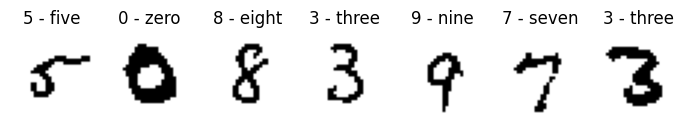

In [2]:
import torch
import matplotlib.pyplot as plt

dl_predict = dm_mnist.predict_dataloader()
x_batch, y_batch = zip(*list(dl_predict))
x_sample = torch.cat(tensors=x_batch, dim=0)
y_sample = torch.cat(tensors=y_batch, dim=0)

# Invert the class index map
idx_to_class = {v: k for k, v in dm_mnist.class_to_idx.items()}

# Plot the first 7 images
fig, axes = plt.subplots(nrows=1, ncols=7, figsize=(7, 3), layout="tight")
for i, ax in enumerate(axes):
    ax.set_title(label=idx_to_class[y_sample[i+100].item()])
    ax.imshow(X=x_sample[i+100].squeeze(), cmap="binary")
    ax.axis("off")

plt.show()

#### Model Module

In [3]:
import torch
import lightning.pytorch as pl

pl.seed_everything(seed=42, workers=True)

# Define the encoder
class Encoder(torch.nn.Module):
    """
    Maps a (1, 28, 28) image to (z_mean, z_log_var).
    """
    def __init__(self, latent_dim: int=2):
        super().__init__()
        self.conv = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=1, out_channels=32, kernel_size=(3, 3),
                stride=(2, 2), padding=(1, 1)),
            torch.nn.ReLU(),
            torch.nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3, 3),
                stride=(2, 2), padding=(1, 1)),
            torch.nn.ReLU(),
            torch.nn.Flatten()
        )
        self.fc_mean = torch.nn.Linear(in_features=64*7*7,
            out_features=latent_dim)
        self.fc_log_var = torch.nn.Linear(in_features=64*7*7,
            out_features=latent_dim)

    def forward(self, x: torch.Tensor):
        x = self.conv(x)
        z_mean = self.fc_mean(x)
        z_log_var = self.fc_log_var(x)
        return z_mean, z_log_var

# Define the decoder
class Decoder(torch.nn.Module):
    """
    Maps a latent vector z back to a (1, 28, 28) image.
    """
    def __init__(self, latent_dim: int=2):
        super().__init__()
        self.deconv = torch.nn.Sequential(
            torch.nn.Linear(in_features=latent_dim, out_features=64*7*7),
            torch.nn.ReLU(),
            torch.nn.Unflatten(dim=1, unflattened_size=(64, 7, 7)),
            torch.nn.ConvTranspose2d(in_channels=64, out_channels=64,
                kernel_size=(3, 3), stride=(2, 2), padding=(1, 1),
                output_padding=(1, 1)),
            torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(in_channels=64, out_channels=32,
                kernel_size=(3, 3), stride=(2, 2), padding=(1, 1),
                output_padding=(1, 1)),
            torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(in_channels=32, out_channels=1,
                kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            torch.nn.Sigmoid()
        )

    def forward(self, z: torch.Tensor):
        x = self.deconv(z)
        return x

# Autoencoder model
class VariationalAutoEncoder(pl.LightningModule):
    def __init__(self, latent_dim: int=2, lr: float=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.encoder = Encoder(latent_dim=latent_dim)
        self.decoder = Decoder(latent_dim=latent_dim)

    def reparameterize(self, z_mean: torch.Tensor, z_log_var: torch.Tensor):
        # z = z_mean + exp(0.5*z_log_var)*epsilon
        std = torch.exp(0.5 * z_log_var)
        epsilon = torch.randn_like(std)
        return z_mean + std * epsilon

    def forward(self, x: torch.Tensor):
        z_mean, z_log_var = self.encoder(x)
        z = self.reparameterize(z_mean, z_log_var)
        x_pred = self.decoder(z)
        return x_pred, z_mean, z_log_var

    def _compute_loss(self, batch, stage: str):
        x, _ = batch
        x_pred, z_mean, z_log_var = self(x)
        # Reconstruction loss: sum over pixels, mean over batch
        recon_loss = torch.nn.functional.binary_cross_entropy(
            input=x_pred, target=x, reduction="none")
        recon_loss = recon_loss.sum(dim=(1, 2, 3)).mean(dim=0)

        # KL divergence loss
        kl_loss = -0.5 * (1 + z_log_var - z_mean.pow(2) - z_log_var.exp())
        kl_loss = kl_loss.sum(dim=1).mean(dim=0)

        total_loss = recon_loss + kl_loss

        self.log_dict(on_step=False, on_epoch=True, sync_dist=True,
            dictionary={
                f"{stage}_loss": torch.log10(total_loss),
                f"{stage}_recon_loss": torch.log10(recon_loss),
                f"{stage}_kl_loss": torch.log10(kl_loss)
            })

        return total_loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(params=self.parameters(),
            lr=self.hparams.lr)

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer=optimizer, mode='min', factor=0.1, patience=3)

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss",
                "frequency": 1
            }
        }

    def training_step(self, batch, batch_idx):
        return self._compute_loss(batch=batch, stage="train")

    def validation_step(self, batch, batch_idx):
        self._compute_loss(batch=batch, stage="val")

    def test_step(self, batch, batch_idx):
        self._compute_loss(batch=batch, stage="test")

    def predict_step(self, batch, batch_idx):
        x, _ = batch
        z_mean, z_log_var = self.encoder(x)
        z = self.reparameterize(z_mean, z_log_var)
        x_pred = self.decoder(z)

        return {
            "x_pred": x_pred,
            "z_mean": z_mean,
            "z_log_var": z_log_var,
        }

latent_dim = 2
VAE = VariationalAutoEncoder(latent_dim=latent_dim)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


#### Probabilistic Model Module

In [4]:
import torch
import lightning.pytorch as pl

pl.seed_everything(seed=42, workers=True)

# Define the encoder
class Encoder(torch.nn.Module):
    def __init__(self, latent_size: int=2):
        super().__init__()
        self.conv = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=1, out_channels=32,
                kernel_size=(3, 3), stride=(2, 2), padding=(1, 1)),
            torch.nn.LeakyReLU(),
            torch.nn.Conv2d(in_channels=32, out_channels=64,
                kernel_size=(3, 3), stride=(2, 2), padding=(1, 1)),
            torch.nn.LeakyReLU(),
            torch.nn.Flatten(),
            torch.nn.Linear(in_features=64*7*7, out_features=2*latent_size)
        )

    def forward(self, x: torch.Tensor):
        x = self.conv(x)
        loc, scale = torch.chunk(x, chunks=2, dim=-1)
        scale = torch.nn.functional.softplus(scale) + 1e-5
        return torch.distributions.Independent(reinterpreted_batch_ndims=1,
            base_distribution=torch.distributions.Normal(loc=loc, scale=scale))

# Define the decoder
class Decoder(torch.nn.Module):
    def __init__(self, latent_size: int=2):
        super().__init__()
        self.deconv = torch.nn.Sequential(
            torch.nn.Linear(in_features=latent_size, out_features=64*7*7),
            torch.nn.LeakyReLU(),
            torch.nn.Unflatten(dim=1, unflattened_size=(64, 7, 7)),
            torch.nn.ConvTranspose2d(in_channels=64, out_channels=64,
                kernel_size=(3, 3), stride=(2, 2), padding=(1, 1),
                output_padding=(1, 1)),
            torch.nn.LeakyReLU(),
            torch.nn.ConvTranspose2d(in_channels=64, out_channels=32,
                kernel_size=(3, 3), stride=(2, 2), padding=(1, 1),
                output_padding=(1, 1)),
            torch.nn.LeakyReLU(),
            torch.nn.ConvTranspose2d(in_channels=32, out_channels=1,
                kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )

    def forward(self, z: torch.Tensor):
        logits = self.deconv(z)
        return torch.distributions.Independent(reinterpreted_batch_ndims=3,
            base_distribution=torch.distributions.Bernoulli(logits=logits))

# Variational AutoEncoder model
class VariationalAutoEncoder(pl.LightningModule):
    def __init__(self, latent_size: int=2, lr: float=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.encoder = Encoder(latent_size=latent_size)
        self.decoder = Decoder(latent_size=latent_size)
        self.register_buffer("prior_loc", torch.zeros(latent_size))
        self.register_buffer("prior_scale", torch.ones(latent_size))

    @property
    def prior(self):
        return torch.distributions.Independent(reinterpreted_batch_ndims=1,
            base_distribution=torch.distributions.Normal(
                loc=self.prior_loc, scale=self.prior_scale))

    def forward(self, x: torch.Tensor):
        q_z = self.encoder(x)
        z = q_z.rsample()
        p_x = self.decoder(z)
        return p_x, q_z

    def _compute_loss(self, batch, stage: str):
        x, _ = batch
        p_x, q_z = self(x)
        nll = -p_x.log_prob(value=x).mean()
        kl = torch.distributions.kl_divergence(p=q_z, q=self.prior).mean()
        loss = nll + kl
        self.log_dict(dictionary={
            f"{stage}_loss": torch.log10(loss),
            f"{stage}_nll": torch.log10(nll),
            f"{stage}_kl": torch.log10(kl)
        }, on_step=False, on_epoch=True, sync_dist=True, prog_bar=True)
        return loss

    def configure_optimizers(self):
        opt = torch.optim.Adam(params=self.parameters(),
            lr=self.hparams.lr)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer=opt, mode='min', factor=0.1, patience=3)
        return {
            "optimizer": opt,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss"
            }
        }

    def training_step(self, batch, batch_idx):
        return self._compute_loss(batch=batch, stage="train")

    def validation_step(self, batch, batch_idx):
        self._compute_loss(batch=batch, stage="val")

    def test_step(self, batch, batch_idx):
        self._compute_loss(batch=batch, stage="test")

    def predict_step(self, batch, batch_idx):
        x, _ = batch
        q_z = self.encoder(x)
        z = q_z.rsample()
        p_x = self.decoder(z)
        return {
            "xhat": p_x.mean,
            "z_mean": q_z.base_dist.mean,
            "z_std": q_z.base_dist.scale,
        }

latent_size = 2
VAE = VariationalAutoEncoder(latent_size=latent_size)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


#### Plot Label Clusters

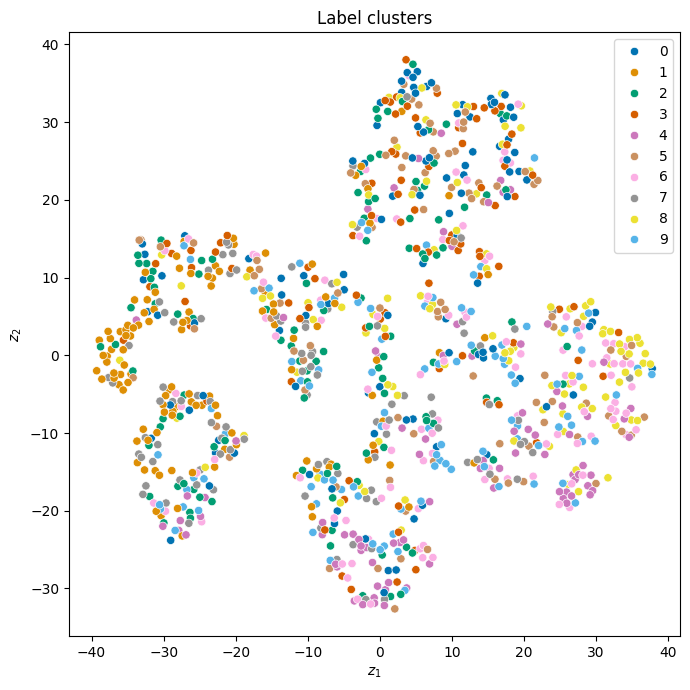

In [6]:
import numpy as np
import torch
from sklearn import manifold
import matplotlib.pyplot as plt
import seaborn as sns

def plot_label_clusters(vae: VAE, data: torch.Tensor, labels: np.ndarray):
    """
    Display a 2D scatter of the digit classes in the latent space.
    """
    vae.eval().to("cpu")
    with torch.no_grad():
        q_z = vae.encoder(x=data.to("cpu"))
        z_mean = q_z.base_dist.mean

    tsne = manifold.TSNE(n_components=2, random_state=42)
    z_mean = tsne.fit_transform(X=z_mean.numpy())

    plt.figure(figsize=(7, 7))
    plt.title(label="Label clusters")
    sns.scatterplot(x=z_mean[:, 0], y=z_mean[:, 1], hue=labels,
        palette=sns.color_palette(palette="colorblind", n_colors=10))
    plt.xlabel(xlabel=r"$z_1$")
    plt.ylabel(ylabel=r"$z_2$")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

plot_label_clusters(vae=VAE, data=x_sample, labels=y_sample)

#### Training

In [7]:
import time
import lightning.pytorch as pl

pl.seed_everything(seed=42, workers=True)

csv_logger = pl.loggers.CSVLogger(save_dir="./lightning_logs",
    name="VariationalAutoEncoder", version="train")
model_ckpt = pl.callbacks.ModelCheckpoint(monitor="val_loss", mode="min",
    dirpath="./ckpt", filename="{epoch}_{val_loss:.6f}")
early_stopping = pl.callbacks.EarlyStopping(monitor="val_loss",
    mode="min", patience=5)
lr_monitor = pl.callbacks.LearningRateMonitor(logging_interval="epoch")
trainer = pl.Trainer(max_epochs=20, logger=csv_logger, log_every_n_steps=1,
    accelerator="auto", enable_progress_bar=True, enable_model_summary=True,
    callbacks=[model_ckpt, early_stopping, lr_monitor])

start_time = time.time()

if __name__ == "__main__":
    VAE.train()
    trainer.fit(model=VAE, datamodule=dm_mnist)

end_time = time.time() - start_time
print("Total training time: %.4fs"%end_time)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder │ Encoder │ 31.4 K │ train │     0 │
│ 1 │ decoder │ Decoder │ 65.1 K │ train │     0 │
└───┴─────────┴─────────┴────────┴───────┴───────┘

Trainable params: 96.5 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 96.5 K                                                                                               
Total estimated model params size (MB): 0.386                                                                      
Modules in train mode: 18                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


Total training time: 567.2072s


#### Plot Training Loss

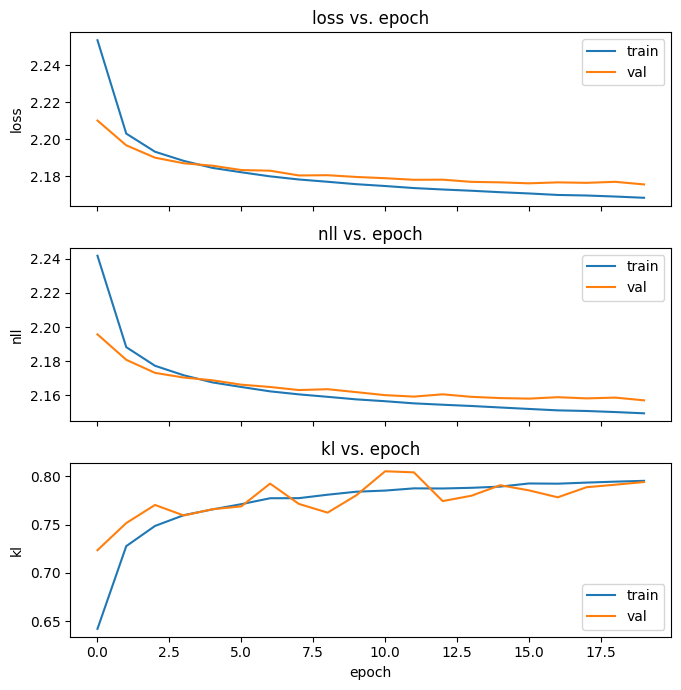

In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

metrics_path = os.path.join(trainer.logger.log_dir, "metrics.csv")
df_metrics = pd.read_csv(metrics_path)

df_metrics = df_metrics.groupby("epoch").agg({
    "train_loss": "mean", "train_nll": "mean", "train_kl": "mean",
    "val_loss": "mean", "val_nll": "mean", "val_kl": "mean"
}).reset_index()

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(7, 7), sharex=True)
for ax, m in zip(axes, ["loss", "nll", "kl"]):
    sns.lineplot(ax=ax, data=df_metrics, x="epoch", y=f"train_{m}",
        label="train")
    sns.lineplot(ax=ax, data=df_metrics, x="epoch", y=f"val_{m}",
        label="val")
    ax.set_ylabel(ylabel=f"{m}")
    ax.set_title(label=f"{m} vs. epoch")
    ax.legend(loc="best")
plt.tight_layout()
plt.show()

#### Prediction

In [9]:
import torch
import lightning.pytorch as pl

pl.seed_everything(seed=42, workers=True)

best_ckpt_path = model_ckpt.best_model_path
VAE = VariationalAutoEncoder.load_from_checkpoint(latent_size=latent_size,
    checkpoint_path=best_ckpt_path)

csv_logger = pl.loggers.CSVLogger(save_dir="./lightning_logs",
    name="VariationalAutoEncoder", version="predict")
trainer = pl.Trainer(max_epochs=1, logger=csv_logger, log_every_n_steps=1,
    accelerator="auto", enable_progress_bar=False, enable_model_summary=False)

if __name__ == "__main__":
    VAE.eval()
    trainer.test(model=VAE, datamodule=dm_mnist)
    predictions = trainer.predict(model=VAE, datamodule=dm_mnist)
    predictions = {k: torch.cat([p[k] for p in predictions], dim=0)
        for k in predictions[0].keys()}

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which sync

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          test_kl          │    0.7946844100952148     │
│         test_loss         │     2.173100471496582     │
│         test_nll          │    2.1544761657714844     │
└───────────────────────────┴───────────────────────────┘

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


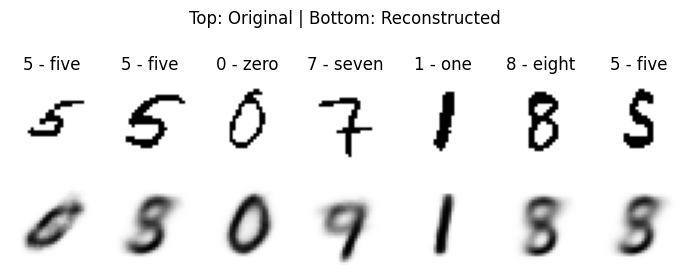

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

xhat_sample = predictions['xhat']
fig, axes = plt.subplots(nrows=2, ncols=7, figsize=(7, 3))
fig.suptitle(t="Top: Original | Bottom: Reconstructed")
for i in range(7):
    ax = axes[0, i]
    ax.set_title(label=idx_to_class[y_sample[i].item()])
    ax.imshow(X=x_sample[i].squeeze(), cmap='binary')
    ax.axis('off')

    ax = axes[1, i]
    ax.imshow(X=xhat_sample[i].squeeze(), cmap='binary')
    ax.axis('off')
plt.tight_layout()
plt.show()

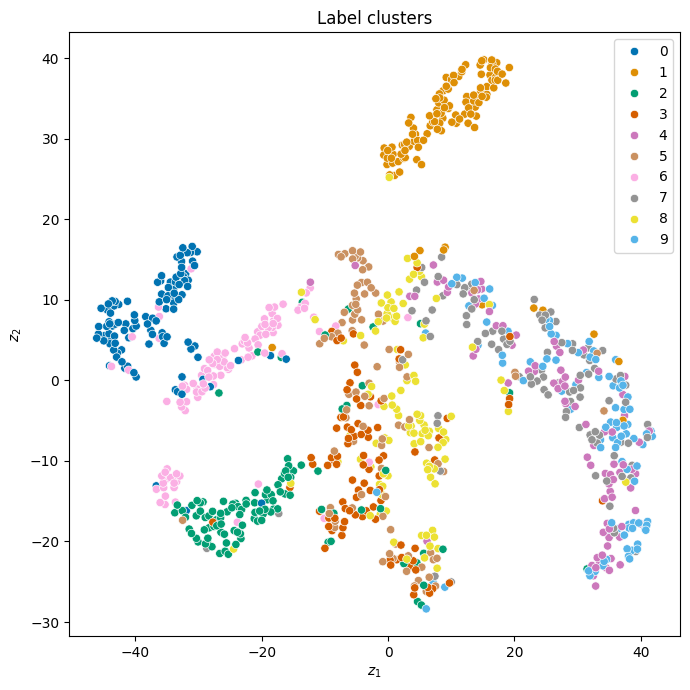

In [11]:
plot_label_clusters(vae=VAE, data=x_sample, labels=y_sample)

The loss function we need to estimate is

\begin{equation*}
-\mathrm{ELBO} = \mathrm{D}_\mathrm{KL} \big[ \ q(z|x) \ || \ p(z) \ \big] - \mathbb{E}_{Z \sim q(z|x)}\big[ \log p(x|Z) \big]\\
\end{equation*}

where $x = (x_1, x_2, \ldots, x_n)$ refers to all observations, $z = (z_1, z_2, \ldots, z_n)$ refers to corresponding latent variables.

Assumed independence of examples implies that we can write this as

\begin{equation*}
\sum_j \mathrm{D}_\mathrm{KL} \big[ \ q(z_j|x_j) \ || \ p(z_j) \ ] - \mathbb{E}_{Z_j \sim q(z_j|x_j)}\big[ \log p(x_j|Z_j) \big]
\end{equation*}

In [ ]:
# Specify the loss function, an estimate of the -ELBO
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import tensorflow_probability as tfp

def loss_fn(x, encoding_dist, sampled_decoding_dist, prior):
    recon_loss = -sampled_decoding_dist.log_prob(value=x)
    kl_loss = tfp.distributions.kl_divergence(distribution_a=encoding_dist,
        distribution_b=prior)
    return tf.math.reduce_sum(input_tensor=kl_loss + recon_loss)

# -ELBO estimate using an estimate of the KL divergence
def loss_fn_MC(x, encoding_dist, sampled_decoding_dist, prior, sampled_z):
    recon_loss = -sampled_decoding_dist.log_prob(value=x)
    kl_approx = (encoding_dist.log_prob(value=sampled_z) - prior.log_prob(value=sampled_z))
    return tf.math.reduce_sum(input_tensor=kl_approx + recon_loss)

In [ ]:
# Define a function that returns the loss and its gradients
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)

@tf.function(reduce_retracing=True)
def get_loss_and_grads(x, encoder, decoder, prior):
    with tf.GradientTape() as tape:
        encoding_dist = encoder(inputs=x)
        sampled_z = encoding_dist.sample()
        sampled_decoding_dist = decoder(inputs=sampled_z)
        loss = loss_fn(x=x, encoding_dist=encoding_dist,
            sampled_decoding_dist=sampled_decoding_dist, prior=prior)

    grads = tape.gradient(target=loss, sources=
        encoder.trainable_variables + decoder.trainable_variables)
    return loss, grads

In [ ]:
# Compile and train the model
import tf_keras
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import matplotlib.pyplot as plt
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)

num_epochs = 10
opt = tf_keras.optimizers.Adam()
losses = []
for i in range(num_epochs):
    for train_batch in x_train:
        loss, grads = get_loss_and_grads(x=train_batch, encoder=encoder,
            decoder=decoder, prior=prior)
        opt.apply_gradients(grads_and_vars=zip(grads,
            encoder.trainable_variables + decoder.trainable_variables))
    losses.append(loss.numpy())

plt.figure(figsize=[6, 3])
plt.plot(losses)
plt.xlabel(xlabel='Epochs')
plt.ylabel(ylabel='-ELBO')
plt.title(label='-ELBO vs. Epochs')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute example encodings after training
posttrain_example_encodings = encoder(inputs=example_x)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=[15, 7])
sns.scatterplot(ax=axes[0], hue=class_names[example_y],
    x=pretrain_example_encodings[:, 0], y=pretrain_example_encodings[:, 1],
    palette=sns.color_palette(palette='colorblind', n_colors=10))
sns.scatterplot(ax=axes[1], hue=class_names[example_y],
    x=posttrain_example_encodings[:, 0], y=posttrain_example_encodings[:, 1],
    palette=sns.color_palette(palette='colorblind', n_colors=10))
axes[0].set_title(label='Encodings of example images before training')
axes[1].set_title(label='Encodings of example images after training')
for ax in axes:
    ax.set_xlabel(xlabel='Encoding dimension 1')
    ax.set_ylabel(ylabel='Encoding dimension 2')
fig.tight_layout()
fig.show()

In [ ]:
# Connect encoder and decoder, compute a reconstruction
def vae(inputs):
    approx_posterior = encoder(inputs=inputs)
    decoding_dist = decoder(inputs=approx_posterior.sample())
    return decoding_dist.mean()

example_reconstruction = vae(inputs=example_x)
example_reconstruction.shape

In [ ]:
# Plot examples against reconstructions
import matplotlib.pyplot as plt

fig, axs = plt.subplots(nrows=2, ncols=6, figsize=[9, 2])
for j in range(6):
    axs[0, j].imshow(X=example_x[j], cmap='binary')
    axs[1, j].imshow(X=example_reconstruction[j], cmap='binary')
    axs[0, j].axis('off')
    axs[1, j].axis('off')
fig.tight_layout()
fig.show()

In [ ]:
# Generate an example - sample a z value, then sample a reconstruction from p(x|z)
z = prior.sample(sample_shape=(6))
generated_x = decoder(inputs=z).mean()
generated_x.shape

In [ ]:
# Display generated_x
import matplotlib.pyplot as plt

fig, axs = plt.subplots(nrows=1, ncols=6, figsize=[9, 1])
for j in range(6):
    axs[j].imshow(X=generated_x[j], cmap='binary')
    axs[j].axis('off')
fig.tight_layout()
fig.show()

***
<a class="anchor" id="tutorial4"></a>
# KL divergence layers

In [ ]:
import tf_keras
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import tensorflow_probability as tfp
import matplotlib.pyplot as plt

latent_size = 4
prior = tfp.distributions.MultivariateNormalDiag(loc=tf.zeros(shape=latent_size))

# approx_posterior.log_prob(value=approx_posterior_sample)
# - prior.log_prob(approx_posterior_sample)
# encoder = tf_keras.Sequential(layers=[
#     tf_keras.Input(shape=12),
#     tf_keras.layers.Dense(units=64, activation=tf.keras.activations.relu),
#     tf_keras.layers.Dense(units=tfp.layers.MultivariateNormalTriL.params_size(
#         event_size=latent_size)),
#     tfp.layers.MultivariateNormalTriL(event_size=latent_size,
#         convert_to_tensor_fn=tfp.distributions.Distribution.sample),
#     tfp.layers.KLDivergenceAddLoss(distribution_b=prior, use_exact_kl=False,
#         weight=10, test_points_fn=lambda q: q.sample(sample_shape=10),
#         test_points_reduce_axis=0) # None, ()
# ])

encoder = tf_keras.Sequential(layers=[
    tf_keras.Input(shape=12),
    tf_keras.layers.Dense(units=64, activation=tf.keras.activations.relu),
    tf_keras.layers.Dense(units=tfp.layers.MultivariateNormalTriL
        .params_size(event_size=latent_size)),
    tfp.layers.MultivariateNormalTriL(event_size=latent_size, activity_regularizer=
        tfp.layers.KLDivergenceRegularizer(distribution_b=prior, use_exact_kl=False,
            weight=10, test_points_fn=lambda q: q.sample(sample_shape=10),
            test_points_reduce_axis=0)) # None, ()
])

decoder = tf_keras.Sequential(layers=[
    tf_keras.Input(shape=latent_size),
    tf_keras.layers.Dense(units=64, activation=tf.keras.activations.relu),
    tf_keras.layers.Dense(units=tfp.layers.IndependentNormal
        .params_size(event_shape=12)),
    tfp.layers.IndependentNormal(event_shape=12)
])

vae = tf_keras.Model(inputs=encoder.input, outputs=decoder(inputs=encoder.output))
vae.compile(
    loss=lambda x, pred: -pred.log_prob(value=x),
    optimizer=tf_keras.optimizers.Adam()
)

x_train = tf.random.normal(shape=[1000, 12], dtype=tf.float32)
x_train = tf.data.Dataset.from_tensor_slices(tensors=x_train)\
    .map(lambda x: (x, x)).batch(batch_size=32)
history = vae.fit(x=x_train, epochs=20, verbose=False)
train_loss = history.history['loss']

plt.figure(figsize=[6, 3])
plt.plot(train_loss)
plt.xlabel(xlabel='Epochs')
plt.ylabel(ylabel='loss')
plt.title(label='Loss vs. Epochs')
plt.tight_layout()
plt.show()

x_test = tf.random.normal(shape=[1, 12], dtype=tf.float32)
x_pred = vae(inputs=x_test).mean()
tf.norm(tensor=x_pred - x_test)

In [ ]:
# Import Fashion MNIST
import numpy as np
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train = x_train.astype('float32')/256. + 0.5/256
x_test = x_test.astype('float32')/256. + 0.5/256
example_x = x_test[:1000]
example_y = y_test[:1000]

class_names = np.array(['T-shirt/top', 'Trouser/pants', 'Pullover shirt',
    'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'])

batch_size = 32
x_train = tf.data.Dataset.from_tensor_slices(tensors=(x_train, x_train))\
    .batch(batch_size=batch_size)
x_test = tf.data.Dataset.from_tensor_slices(tensors=(x_test, x_test))\
    .batch(batch_size=batch_size)

fig, axes = plt.subplots(nrows=1, ncols=5, figsize=[9, 1])
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X=example_x[i], cmap='binary')
    ax.axis('off')
fig.tight_layout()
fig.show()

In [ ]:
# Define latent_size and the prior, p(z)
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import tensorflow_probability as tfp

latent_size = 4
prior = tfp.distributions.MultivariateNormalDiag(loc=tf.zeros(shape=latent_size))
prior

In [ ]:
# Define the encoding distribution using a tfpl.KLDivergenceAddLoss layer
import tf_keras
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import tensorflow_probability as tfp

# samples z_j from q(z|x_j)
# then computes log q(z_j|x_j) - log p(z_j)
event_shape = [28, 28]
encoder = tf_keras.Sequential(layers=[
    tf_keras.Input(shape=event_shape),
    tf_keras.layers.Flatten(),
    tf_keras.layers.Dense(units=128, activation=tf.keras.activations.relu),
    tf_keras.layers.Dense(units=64, activation=tf.keras.activations.relu),
    tf_keras.layers.Dense(units=32, activation=tf.keras.activations.relu),
    tf_keras.layers.Dense(units=16, activation=tf.keras.activations.relu),
    tf_keras.layers.Dense(units=tfp.layers.MultivariateNormalTriL
        .params_size(event_size=latent_size)),
    tfp.layers.MultivariateNormalTriL(event_size=latent_size),
    # estimates KL[q(z|x)||p(z)]
    tfp.layers.KLDivergenceAddLoss(distribution_b=prior)
])

# See how `KLDivergenceAddLoss` affects `encoder.losses`
# encoder.losses before the network has received any inputs
encoder.losses

In [ ]:
# Pass a batch of images through the encoder
encoder(inputs=example_x)
# See how encoder.losses has changed
encoder.losses

In [ ]:
# Re-specify the encoder using `weight` and `test_points_fn`
import tf_keras
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import tensorflow_probability as tfp

encoder = tf_keras.Sequential(layers=[
    tf_keras.Input(shape=event_shape),
    tf_keras.layers.Flatten(),
    tf_keras.layers.Dense(units=128, activation=tf.keras.activations.relu),
    tf_keras.layers.Dense(units=64, activation=tf.keras.activations.relu),
    tf_keras.layers.Dense(units=32, activation=tf.keras.activations.relu),
    tf_keras.layers.Dense(units=16, activation=tf.keras.activations.relu),
    tf_keras.layers.Dense(units=tfp.layers.MultivariateNormalTriL
        .params_size(event_size=latent_size)),
    tfp.layers.MultivariateNormalTriL(event_size=latent_size),
    tfp.layers.KLDivergenceAddLoss(distribution_b=prior, use_exact_kl=False,
        weight=1.5, test_points_fn=lambda q: q.sample(sample_shape=10),
        test_points_reduce_axis=0) # estimates KL[q(z|x)||p(z)]
])

# (n_samples, batch_size, dim_z)
# z_{ij} is the ith sample for x_j (is at (i,j,:) in tensor of samples)
# is mapped to log q(z_{ij}|x_j) - log p(z_{ij})
# => tensor of KL divergences has shape (n_samples, batch_size)

# Pass a batch of images through the encoder
encoder(inputs=example_x)
# See how encoder.losses has changed
encoder.losses

In [ ]:
# Replacing `KLDivergenceAddLoss`  with `KLDivergenceRegularizer` in the previous (probabilistic) layer
import tf_keras
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import tensorflow_probability as tfp

divergence_regularizer = tfp.layers.KLDivergenceRegularizer(distribution_b=prior,
    use_exact_kl=False, test_points_fn=lambda q: q.sample(sample_shape=5),
    test_points_reduce_axis=0)

event_shape = [28, 28]
encoder = tf_keras.Sequential(layers=[
    tf_keras.Input(shape=event_shape),
    tf_keras.layers.Flatten(),
    tf_keras.layers.Dense(units=128, activation=tf.keras.activations.relu),
    tf_keras.layers.Dense(units=64, activation=tf.keras.activations.relu),
    tf_keras.layers.Dense(units=32, activation=tf.keras.activations.relu),
    tf_keras.layers.Dense(units=16, activation=tf.keras.activations.relu),
    tf_keras.layers.Dense(units=tfp.layers.MultivariateNormalTriL
        .params_size(event_size=latent_size)),
    tfp.layers.MultivariateNormalTriL(event_size=latent_size,
        activity_regularizer=divergence_regularizer)
])

# Pass a batch of images through the encoder
encoder(inputs=example_x)
# See how encoder.losses has changed
encoder.losses

In [ ]:
# Specify the decoder, p(x|z)
import tf_keras
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)
import tensorflow_probability as tfp

decoder = tf_keras.Sequential(layers=[
    tf_keras.Input(shape=latent_size),
    tf_keras.layers.Dense(units=16, activation=tf.keras.activations.sigmoid),
    tf_keras.layers.Dense(units=32, activation=tf.keras.activations.sigmoid),
    tf_keras.layers.Dense(units=64, activation=tf.keras.activations.sigmoid),
    tf_keras.layers.Dense(units=2*event_shape[0]*event_shape[1],
        activation=tf.keras.activations.exponential),
    tf_keras.layers.Reshape(target_shape=(event_shape[0], event_shape[1], 2)),
    tfp.layers.DistributionLambda(make_distribution_fn=lambda t:
        tfp.distributions.Independent(distribution=tfp.distributions.Beta(
            concentration1=t[..., 0], concentration0=t[..., 1]),
            reinterpreted_batch_ndims=2))
])

decoder(inputs=encoder(inputs=example_x))

In [ ]:
# Connect the encoder and decoder to form the VAE
import tf_keras
import tensorflow as tf
tf.keras.utils.set_random_seed(seed=42)

vae = tf_keras.Model(inputs=encoder.inputs, outputs=decoder(inputs=encoder.outputs))

# Define a loss that only estimates the expected reconstruction error,
# -E_{Z ~ q(z|x)}[log p(x|Z)]
def log_loss(x_true, p_x_given_z):
    return -tf.math.reduce_sum(input_tensor=p_x_given_z.log_prob(value=x_true))

# Compile the model
vae.compile(loss=log_loss, optimizer=tf_keras.optimizers.Adam())

In [ ]:
import matplotlib.pyplot as plt

# Fit the model
history = vae.fit(x=x_train, validation_data=x_test, epochs=10, verbose=False)
train_loss = history.history['loss']
val_loss = history.history['val_loss']
plt.figure(figsize=[6, 3])
plt.plot(train_loss, label='train')
plt.plot(val_loss, label='val')
plt.xlabel(xlabel='Epochs')
plt.ylabel(ylabel='loss')
plt.title(label='Loss vs. Epochs')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Generate an example reconstruction
example_reconstruction = vae(inputs=example_x).mean()
example_reconstruction.shape

In [ ]:
# Plot the example reconstructions
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=2, ncols=6, figsize=[9, 2])
for j in range(6):
    axes[0, j].imshow(X=example_x[j], cmap='binary')
    axes[1, j].imshow(X=example_reconstruction[j], cmap='binary')
    axes[0, j].axis('off')
    axes[1, j].axis('off')
fig.tight_layout()
fig.show()